# Real CS2–IS2 1D multi-output GP inversion: March 2020

This notebook is the first real-data bridge from the supervisor's
`MultioutputGPPlayground.ipynb` to the dissertation workflow.

The input is a derived 1D transect from the CPOM server data:

- source files: the 15-day `March_8.pkl` windows for CS2 and IS2;
- original fields: `x`, `y`, `t`, `z`, where `z` is freeboard in metres;
- processing: round to the shared 25 km EASE grid, average within each grid
  cell over the window, inner-join CS2 and IS2, remove negative CS2 and
  non-positive IS2 values;
- transect: the fixed-$y$ row with the largest number of collocated cells;
- final sample: 74 paired locations at $y=-487{,}500$ m.

This is an **exploratory inversion**, not an independent validation. There is
no observed ground truth for $H_i$ or $H_s$ in this notebook. Observation-space
residuals measure fit to the same freeboards used for training and must not be
reported as validation RMSE.


In [1]:
import numpy as np
from math import sqrt
import matplotlib.pyplot as plt
import gpflow
from gpflow.likelihoods import Gaussian, Likelihood
from gpflow.models import GPR, GPModel
from gpflow.utilities.parameter_or_function import (
    ConstantOrFunction,
    ParameterOrFunction,
    evaluate_parameter_or_function,
    prepare_parameter_or_function,
)
from gpflow.models.util import data_input_to_tensor
from gpflow.utilities import add_likelihood_noise_cov
from gpflow.logdensities import multivariate_normal
from gpflow.mean_functions import MeanFunction, Zero
from check_shapes import check_shapes, inherit_check_shapes
import tensorflow as tf
from typing import Optional
from copy import copy
import sys

print('Python:', sys.version)
print('TensorFlow:', tf.__version__)
print('GPflow:', gpflow.__version__)


Python: 3.12.13 (main, Mar  3 2026, 15:35:03) [Clang 21.1.4 ]
TensorFlow: 2.16.2
GPflow: 2.11.1


In [2]:
class LinearModelLikelihood(Likelihood):
    """
    Implements Gaussian likelihood of form y = Hx + noise
    """
    def __init__(self, input_dim, variance, H):
        observation_dim, latent_dim = H.shape
        super().__init__(input_dim=input_dim, latent_dim=latent_dim, observation_dim=observation_dim)

        if isinstance(variance, (int, float)):
            variance = variance*tf.eye(observation_dim, dtype=tf.float64)

        assert variance.shape == (observation_dim, observation_dim)

        self.variance = prepare_parameter_or_function(variance) # Converts variance to gpflow parameter
        self.H = H

    @staticmethod
    @check_shapes(
        "x: [broadcast shape..., input_dim]",
        "mu: [broadcast shape..., P]",
        "cov: [broadcast shape..., P, P]",
        "return: [shape...]",
    )
    def multivariate_gaussian_log_density(x, mu, cov) -> tf.Tensor:
        P = mu.shape[-1]
        diff = tf.expand_dims(mu-x, axis=-1) # (..., P, 1)
        shape = tf.concat([tf.shape(mu)[:-1], [P, P]], axis=0)
        cov_broadcast = tf.broadcast_to(cov, shape) # (..., P, P)
        out = - (P/2) * np.log(2 * np.pi) \
              - 0.5 * tf.linalg.logdet(cov) \
              - 0.5 * tf.linalg.matmul(diff, tf.linalg.solve(cov_broadcast, diff), transpose_a=True) # (..., 1, 1)
        return tf.reduce_sum(out, [-1,-2]) # (..., 1, 1) -> (...)

    @check_shapes(
        "X: [batch..., N, D]",
        "return: [batch..., N, P, P]",
    )
    def variance_at(self, X) -> tf.Tensor:
        variance = self.variance
        P = variance.shape[0]
        shape = tf.concat([tf.shape(X)[:-1], [P, P]], 0)
        return tf.broadcast_to(variance, shape)

    @inherit_check_shapes
    def _log_prob(self, X, F, Y) -> tf.Tensor:
        HF = tf.linalg.matvec(self.H, F)
        # return gpflow.logdensities.gaussian(Y, HF, self.variance) # Note: only deals with scalar y
        return self.multivariate_gaussian_log_density(Y, HF, self.variance)

    @inherit_check_shapes
    def _conditional_mean(self, X, F) -> tf.Tensor:
        HF = tf.linalg.matvec(self.H, F)
        return tf.identity(HF)

    @inherit_check_shapes
    def _conditional_variance(self, X, F) -> tf.Tensor:
        shape = (tf.shape(F)[0], self.observation_dim)
        return tf.broadcast_to(self.variance, shape)

    @check_shapes(
        "X: [broadcast batch..., input_dim]",
        "Fmu: [broadcast batch..., latent_dim]",
        "Fcov: [broadcast batch..., latent_dim, latent_dim]",
        "return[0]: [batch..., observation_dim]",
        "return[1]: [batch..., observation_dim, observation_dim]",
    )
    def _predict_mean_and_var(self, X, Fmu, Fcov) -> tf.Tensor:
        HFmu = tf.linalg.matvec(self.H, Fmu)
        HFcovHt = self.H @ Fcov @ tf.transpose(self.H)
        return tf.identity(HFmu), HFcovHt + self.variance

    def predict_mean_and_var(self, X, Fmu, Fcov):
        return self._predict_mean_and_var(X, Fmu, Fcov)

    @check_shapes(
        "X: [broadcast batch..., input_dim]",
        "Fmu: [broadcast batch..., latent_dim]",
        "Fcov: [broadcast batch..., latent_dim, latent_dim]",
        "return: [batch...]",
    )
    def _predict_log_density(self, X, Fmu, Fcov, Y) -> tf.Tensor:
        HFmu = tf.linalg.matvec(self.H, Fmu) # Shape (..., P)
        HFcovHt = self.H @ Fcov @ tf.transpose(self.H) # Shape (..., P, P)
        return self.multivariate_gaussian_log_density(Y, HFmu, HFcovHt + self.variance)

    def predict_log_density(self, X, Fmu, Fcov, Y):
        return self._predict_log_density(X, Fmu, Fcov, Y)

    @check_shapes(
        "X: [broadcast batch..., input_dim]",
        "Fmu: [broadcast batch..., latent_dim]",
        "Fcov: [broadcast batch..., latent_dim, latent_dim]",
        "return: [batch...]",
    )
    def _variational_expectations(self, X, Fmu, Fcov, Y) -> tf.Tensor:
        HFmu = tf.linalg.matvec(self.H, Fmu) # Shape (..., P)
        HFcovHt = self.H @ Fcov @ tf.transpose(self.H) # Shape (..., P, P)
        covariance = self.variance # (P, P)
        shape = tf.concat([tf.shape(HFmu)[:-1], tf.shape(covariance)], axis=0)
        cov_broadcast = tf.broadcast_to(covariance, shape) # (..., P, P)
        P = self.observation_dim
        diff = tf.expand_dims(Y-HFmu, axis=-1) # Shape (..., P, 1)
        output = - (P/2) * np.log(2 * np.pi) \
                 - 0.5 * tf.linalg.logdet(covariance) \
                 - 0.5 * tf.squeeze(tf.matmul(diff, tf.linalg.solve(cov_broadcast, diff), transpose_a=True)) \
                 - 0.5 * tf.linalg.trace(tf.linalg.solve(cov_broadcast, HFcovHt))
        return output

    def variational_expectations(self, X, Fmu, Fcov, Y):
        return self._variational_expectations(X, Fmu, Fcov, Y)


class MultioutputGPR(GPR):
    """
    Module for Gaussian process regression in the multi-output setting
    In the comments we use the following notations:
    M: Training size, N: Test Size, L: Latent GP dimension, P: Observation dimension
    """
    def __init__(self,
                 data,
                 kernel,
                 num_latent_gps,
                 mean_function = None,
                 noise_variance = None,
                 likelihood: LinearModelLikelihood = None):
        assert (noise_variance is None) or (
            likelihood is None
        ), "Cannot set both `noise_variance` and `likelihood`."
        if likelihood is None:
            if noise_variance is None:
                noise_variance = 1.0
            likelihood = gpflow.likelihoods.Gaussian(noise_variance)
        _, Y_data = data

        GPModel.__init__(self, kernel, likelihood, mean_function, num_latent_gps=num_latent_gps)

        self.data = data_input_to_tensor(data)

        if mean_function is None:
            self.mean_function = Zero(output_dim=Y_data.shape[-1])

    @staticmethod
    @check_shapes(
        "K: [batch..., N, N, P, P]",
        "return: [batch..., N, N, P, P]",
    ) # TODO: Simplify by taking shape [N, P, N, P] instead
    def add_likelihood_noise_cov(K, likelihood: LinearModelLikelihood):
        R = likelihood.variance # Shape (P, P)
        N, P = K.shape[-3], K.shape[-1]
        # Construct a block-diagonal matrix of R's to add to K
        R_op = tf.linalg.LinearOperatorFullMatrix(R)
        R_op_diag = tf.linalg.LinearOperatorBlockDiag([R_op for _ in range(N)]) # Shape (N*P, N*P)
        # Reshape K to tensor of hape (..., N*P, N*P)
        axis_indices = [i for i in range(len(K.shape))]
        leading_indices, tensor_indices = axis_indices[:-4], axis_indices[-4:]
        tensor_indices_permuted = [tensor_indices[0], tensor_indices[2], tensor_indices[1], tensor_indices[3]]
        K = tf.transpose(K, leading_indices+tensor_indices_permuted) # Shape (..., N, P, N, P)
        leading_dims = K.shape[:-4]
        K = tf.reshape(K, leading_dims+[N*P, N*P]) # Shape (..., N*P, N*P)
        # Add R's to the diagonal of K and reshape
        KnR = R_op_diag.add_to_tensor(K) # Shape (..., N*P, N*P)
        KnR = tf.reshape(KnR, leading_dims+[N, P, N, P]) # Shape (..., N, P, N, P)
        return tf.transpose(KnR, leading_indices+tensor_indices_permuted) # Shape (..., N, N, P, P)

    @check_shapes(
        "Kmn: [M, L, N, L]",
        "Kmm: [M, L, M, L]",
        "Knn: [N, L, N, L] if full_cov",
        "Knn: [N, L, L] if not full_cov",
        "f: [M, P]",
        "return[0]: [N, L]",
        "return[1]: [N, L, N, L] if full_cov",
        "return[1]: [N, L, L] if not full_cov",
    )
    def multioutput_conditional(self,
                                Kmn: tf.Tensor, # Shape (M, L, N, L)
                                Kmm: tf.Tensor, # Shape (M, L, M, L)
                                Knn: tf.Tensor, # Shape (N, L, N, L)
                                f: tf.Tensor, # Shape (M, P)
                                *,
                                full_cov=False):

        Kmn = tf.transpose(Kmn, [0,2,1,3]) # Shape (M, N, L, L)
        Kmm = tf.transpose(Kmm, [0,2,1,3]) # Shape (M, M, L, L)
        H = self.likelihood.H

        HKmmHt = H @ Kmm @ tf.transpose(H) # Shape (M, M, P, P)
        HKmn = H @ Kmn # Shape (M, N, P, L)
        ks = self.add_likelihood_noise_cov(HKmmHt, self.likelihood) # Shape (M, M, P, P)
        ks = tf.transpose(ks, [0,2,1,3]) # Shape (M, P, M, P)
        N, P, M, _ = ks.shape
        ks = tf.reshape(ks, (M*P, M*P)) # Reshape to size (MP, MP)
        Lm = tf.linalg.cholesky(ks) # Shape (MP, MP)

        # Compute the projection matrix A
        HKmn = tf.transpose(HKmn, [0,2,1,3]) # Shape (M, P, N, L)
        M, P, N, L = HKmn.shape
        HKmn = tf.reshape(HKmn, (M*P, N*L)) # Reshape to size (MP, NL)
        A = tf.linalg.triangular_solve(Lm, HKmn, lower=True)  # Shape (MP, NL)

        # Compute conditional covariance
        if full_cov:
            Knn = tf.reshape(Knn, (N*L, N*L))
            fvar = Knn - tf.linalg.matmul(A, A, transpose_a=True) # Shape (NL, NL)
            fvar = tf.reshape(fvar, (N, L, N, L))
        else:
            def square(tensor):
                """Input is a tensor of shape (M, P, L) """
                tensor = tf.reshape(tensor, (M*P, L)) # Reshape to size (MP, L)
                return tf.linalg.matmul(tensor, tensor, transpose_a=True) # Shape (L, L)

            A = tf.reshape(A, (M, P, N, L))
            AtA_diag = tf.stack([square(A[:,:,n,:]) for n in range(N)], 0) # Shape (N, L, L)
            fvar = Knn - AtA_diag
            A = tf.reshape(A, (M*P, N*L))

        # Compute conditional mean
        f = tf.reshape(f, (M*P,1)) # Shape (MP, 1)
        A = tf.linalg.triangular_solve(tf.linalg.adjoint(Lm), A, lower=False) # Shape (MP, NL)
        fmean = tf.linalg.matmul(A, f, transpose_a=True) # Shape (NL, 1)
        fmean = tf.reshape(fmean, (N,L)) # Shape (N, L)

        return fmean, fvar

    @inherit_check_shapes
    def log_marginal_likelihood(self) -> tf.Tensor:
        X, Y = self.data
        H = self.likelihood.H
        K = self.kernel(X, full_cov=True, full_output_cov=True) # Shape (N, L, N, L)
        K = tf.transpose(K, [0,2,1,3]) # Shape (N, N, L, L)
        HKHt = H @ K @ tf.transpose(H) # Shape (N, N, P, P)
        ks = self.add_likelihood_noise_cov(HKHt, self.likelihood) # Shape (N, N, P, P)
        ks = tf.transpose(ks, [0,2,1,3]) # Shape (N, P, N, P)
        N, P = ks.shape[:2]
        ks = tf.reshape(ks, (N*P, N*P)) # Shape (NP, NP)
        L = tf.linalg.cholesky(ks)
        m = self.mean_function(X)
        log_prob = multivariate_normal(tf.reshape(Y, (N*P, 1)),
                                       tf.reshape(m, (N*P, 1)),
                                       L
                    )
        return tf.reduce_sum(log_prob)

    @inherit_check_shapes
    def predict_f(
        self, Xnew, full_cov: bool = False, full_output_cov: bool = False
    ):
        X, Y = self.data
        err = Y - self.mean_function(X) # TODO: Handle multivariate mean properly. Shape (M, P)

        kmm = self.kernel(X, full_cov=True, full_output_cov=True) # Shape (M, L, M, L)
        knn = self.kernel(Xnew, full_cov=full_cov, full_output_cov=True) # Shape (N, L, N, L)
        kmn = self.kernel(X, Xnew, full_cov=True, full_output_cov=True) # Shape (M, L, N, L)

        f_mean_zero, f_var = self.multioutput_conditional(
            kmn, kmm, knn, err, full_cov=full_cov
        )  # [N, P], [N, P] or [P, N, N]

        f_mean = f_mean_zero + self.mean_function(Xnew)

        if not full_output_cov:
            f_var = tf.linalg.diag_part(f_var)

        return f_mean, f_var

## 1. Load the server-derived transect


In [3]:
data = np.genfromtxt(
    '../data/processed/real_data_March8_1D_transect.csv',
    delimiter=',', names=True, dtype=None, encoding='utf-8'
)

distance_km = np.asarray(data['distance_km'], dtype=np.float64)
x_m = np.asarray(data['x_m'], dtype=np.float64)
y_m = np.asarray(data['y_m'], dtype=np.float64)
freeboard_cs2 = np.asarray(data['freeboard_cs2_m'], dtype=np.float64)
freeboard_is2 = np.asarray(data['freeboard_is2_m'], dtype=np.float64)
n_cs2 = np.asarray(data['n_cs2'], dtype=np.int64)
n_is2 = np.asarray(data['n_is2'], dtype=np.int64)

# Express the model input in 1000 km units for numerically interpretable kernels.
X = (distance_km / 1000.0)[:, None]
Y = np.column_stack([freeboard_cs2, freeboard_is2])

print('rows:', len(X))
print('fixed y (m):', np.unique(y_m))
print('distance range (km):', (distance_km.min(), distance_km.max()))
print('CS2 freeboard range (m):', (freeboard_cs2.min(), freeboard_cs2.max()))
print('IS2 freeboard range (m):', (freeboard_is2.min(), freeboard_is2.max()))
print('median observations per cell:', {'CS2': np.median(n_cs2), 'IS2': np.median(n_is2)})


rows: 74
fixed y (m): [-487500.]
distance range (km): (0.0, 4975.0)
CS2 freeboard range (m): (0.003876923076923085, 0.2694117647058824)
IS2 freeboard range (m): (0.11982659963593967, 0.6269680442980299)
median observations per cell: {'CS2': 2.0, 'IS2': 1.0}


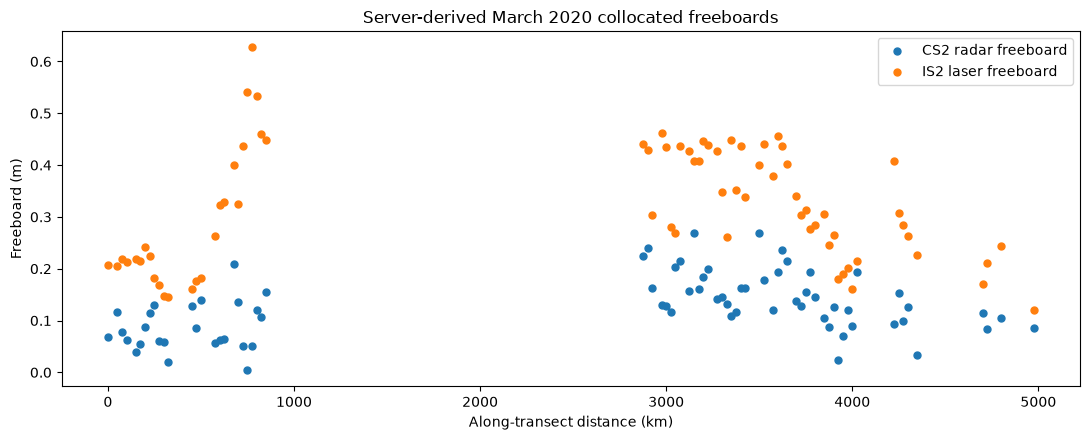

In [4]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.scatter(distance_km, freeboard_cs2, s=25, label='CS2 radar freeboard')
ax.scatter(distance_km, freeboard_is2, s=25, label='IS2 laser freeboard')
ax.set_xlabel('Along-transect distance (km)')
ax.set_ylabel('Freeboard (m)')
ax.legend()
ax.set_title('Server-derived March 2020 collocated freeboards')
plt.tight_layout()


## 2. Existing CPOM-project physical assumptions

The constants below match the existing CPOM project implementation so
this experiment can be compared with the existing processing chain. They are
not treated as universally correct: density and penetration sensitivity must be
evaluated before scientific interpretation.


In [5]:
rho_w = 1024.0
rho_i = 915.0
rho_s = 300.0
c = 299792458.0
c_s = 229792458.0
alpha_cs = 1.0
alpha_is = 0.0

c_over_cs = c / c_s
A = (rho_w - rho_i) / rho_w
B_cs = 1.0 - alpha_cs*c_over_cs - rho_s/rho_w
B_is = 1.0 - alpha_is*c_over_cs - rho_s/rho_w
H = np.array([[A, B_cs], [A, B_is]], dtype=np.float64)

# Initial constant observation uncertainties; later replace with documented,
# sensor-specific and aggregation-aware uncertainty estimates.
sigma_cs = 0.03
sigma_is = 0.02
R = np.diag([sigma_cs**2, sigma_is**2]).astype(np.float64)

print('H =\n', H)
print('det(H) =', np.linalg.det(H))
print('condition number(H) =', np.linalg.cond(H))


H =
 [[ 0.10644531 -0.59759145]
 [ 0.10644531  0.70703125]]
det(H) = 0.1388709714613572
condition number(H) = 6.172430026694078


## 3. Pointwise algebraic inversion baseline


Pointwise Hi range (m): (0.7253905381851841, 3.1269549640127114)
Pointwise Hs range (m): (0.015303239112442127, 0.44214357328402903)
Pointwise medians (m): {'Hi': 2.025595553087964, 'Hs': 0.1349524783845929}
Unphysical negatives: {'Hi': 0, 'Hs': 0}


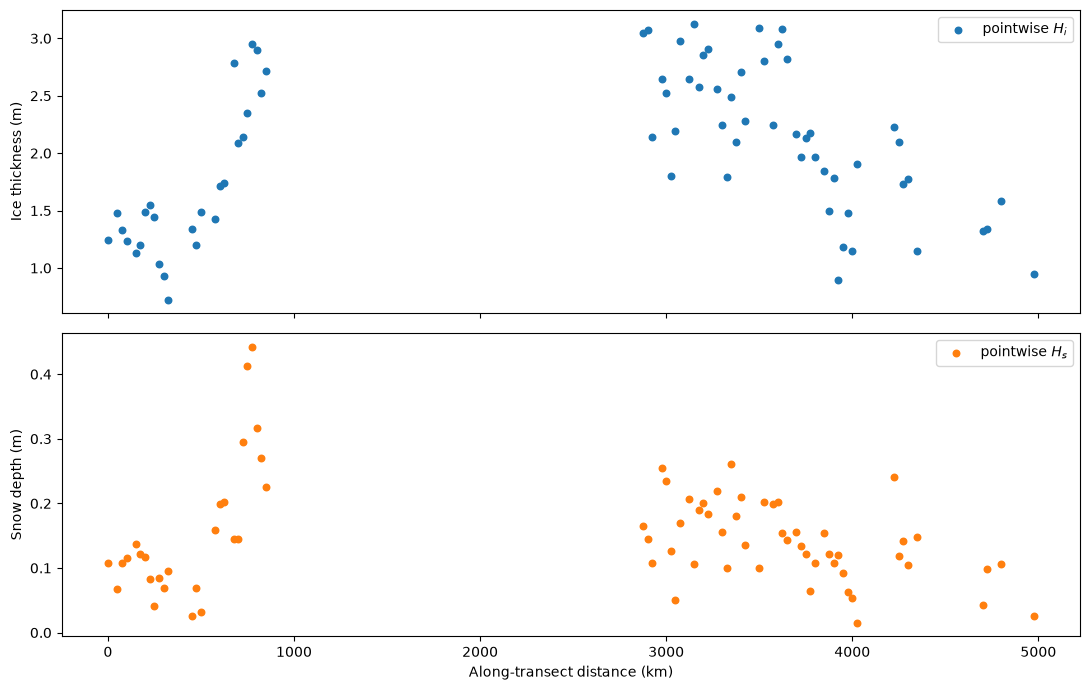

In [6]:
f_point = np.linalg.solve(H, Y.T).T
Hi_point = f_point[:, 0]
Hs_point = f_point[:, 1]

print('Pointwise Hi range (m):', (Hi_point.min(), Hi_point.max()))
print('Pointwise Hs range (m):', (Hs_point.min(), Hs_point.max()))
print('Pointwise medians (m):', {'Hi': np.median(Hi_point), 'Hs': np.median(Hs_point)})
print('Unphysical negatives:', {'Hi': int((Hi_point < 0).sum()), 'Hs': int((Hs_point < 0).sum())})

fig, axs = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axs[0].scatter(distance_km, Hi_point, s=22, label='pointwise $H_i$')
axs[0].set_ylabel('Ice thickness (m)')
axs[0].legend()
axs[1].scatter(distance_km, Hs_point, s=22, color='C1', label='pointwise $H_s$')
axs[1].set_ylabel('Snow depth (m)')
axs[1].set_xlabel('Along-transect distance (km)')
axs[1].legend()
plt.tight_layout()


## 4. Exact multi-output GP inversion


In [7]:
latent_baseline = np.array([1.5, 0.15], dtype=np.float64)
observation_baseline = H @ latent_baseline
Y_centered = Y - observation_baseline

# 1 input unit equals 1000 km. Initial length scales are therefore 400 and 300 km.
kern_hi = gpflow.kernels.Matern52(lengthscales=0.4, variance=1.0)
kern_hs = gpflow.kernels.Matern52(lengthscales=0.3, variance=1.0)
W_prior = np.array([[0.45, 0.00], [0.00, 0.10]], dtype=np.float64)
kernel = gpflow.kernels.LinearCoregionalization([kern_hi, kern_hs], W=W_prior)
likelihood = LinearModelLikelihood(input_dim=1, variance=R, H=H)
model = MultioutputGPR(
    data=(X, Y_centered), kernel=kernel, likelihood=likelihood, num_latent_gps=2
)

gpflow.utilities.set_trainable(model.kernel.W, False)
gpflow.utilities.set_trainable(model.likelihood.variance, False)

opt = gpflow.optimizers.Scipy()
opt_logs = opt.minimize(
    model.training_loss, model.trainable_variables, options=dict(maxiter=2000)
)
print(opt_logs)
gpflow.utilities.print_summary(model)


2026-08-08 20:40:29.939619: W external/local_tsl/tsl/platform/profile_utils/cpu_utils.cc:145] Failed to get CPU frequency: 0 Hz


  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -193.75766101520807
        x: [-2.842e+00  2.491e+00 -3.224e+00 -3.435e-01]
      nit: 13
      jac: [-1.440e-05  7.867e-05 -7.294e-07 -2.522e-05]
     nfev: 17
     njev: 17
 hess_inv: <4x4 LbfgsInvHessProduct with dtype=float64>
╒═══════════════════════════════════════════════╤═══════════╤═════════════╤═════════╤═════════════╤═════════╤═════════╤══════════════════════╕
│ name                                          │ class     │ transform   │ prior   │ trainable   │ shape   │ dtype   │ value                │
╞═══════════════════════════════════════════════╪═══════════╪═════════════╪═════════╪═════════════╪═════════╪═════════╪══════════════════════╡
│ MultioutputGPR.kernel.kernels[0].variance     │ Parameter │ Softplus    │         │ True        │ ()      │ float64 │ 2.57102              │
├───────────────────────────────────────────────┼───────────┼─────────────┼─────────┼───────

## 5. Posterior latent fields and observation-space fit


In [8]:
X_dense = np.linspace(X.min(), X.max(), 500)[:, None]
distance_dense_km = X_dense[:, 0] * 1000.0

f_dense_dev, v_dense = model.predict_f(X_dense)
f_dense = f_dense_dev.numpy() + latent_baseline
s_dense = np.sqrt(np.maximum(v_dense.numpy(), 0.0))

f_obs_dev, v_obs = model.predict_f(X)
f_obs = f_obs_dev.numpy() + latent_baseline
Y_reconstructed = f_obs @ H.T
residual = Y_reconstructed - Y

def rmse(values):
    return float(np.sqrt(np.mean(values**2)))

print('GP Hi range on dense transect (m):', (f_dense[:,0].min(), f_dense[:,0].max()))
print('GP Hs range on dense transect (m):', (f_dense[:,1].min(), f_dense[:,1].max()))
print('Negative dense predictions:', {
    'Hi': int((f_dense[:,0] < 0).sum()), 'Hs': int((f_dense[:,1] < 0).sum())
})
print('Training freeboard fit RMSE — not validation:', {
    'CS2': rmse(residual[:,0]), 'IS2': rmse(residual[:,1])
})


GP Hi range on dense transect (m): (0.7710042624979645, 3.064723510722996)
GP Hs range on dense transect (m): (0.03369018094943384, 0.4268299521028742)
Negative dense predictions: {'Hi': 0, 'Hs': 0}
Training freeboard fit RMSE — not validation: {'CS2': 0.015882411941619295, 'IS2': 0.013154099428153192}


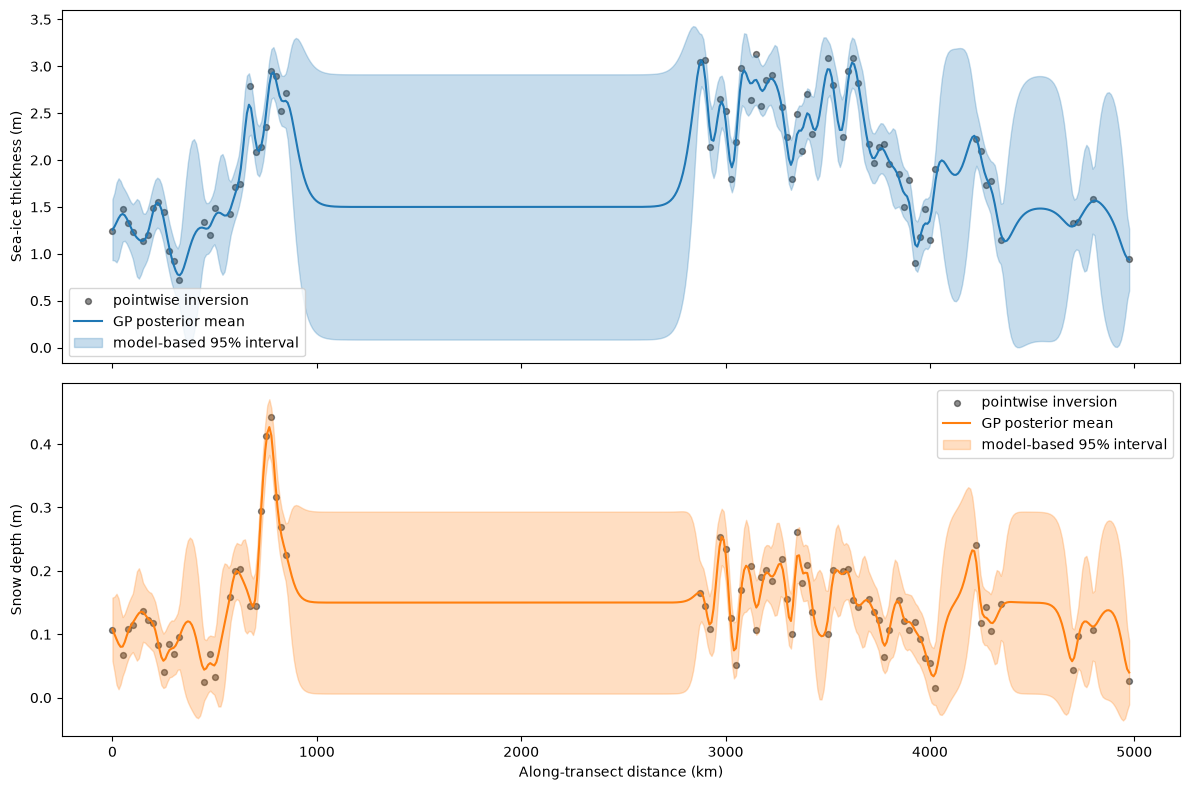

In [9]:
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
names = [('Sea-ice thickness', 'C0'), ('Snow depth', 'C1')]
point = [Hi_point, Hs_point]
for j, ax in enumerate(axs):
    label, color = names[j]
    ax.scatter(distance_km, point[j], s=18, color='black', alpha=0.45,
               label='pointwise inversion')
    ax.plot(distance_dense_km, f_dense[:,j], color=color, label='GP posterior mean')
    ax.fill_between(
        distance_dense_km,
        f_dense[:,j] - 1.96*s_dense[:,j],
        f_dense[:,j] + 1.96*s_dense[:,j],
        color=color, alpha=0.25, label='model-based 95% interval'
    )
    ax.set_ylabel(label + ' (m)')
    ax.legend(loc='best')
axs[-1].set_xlabel('Along-transect distance (km)')
plt.tight_layout()


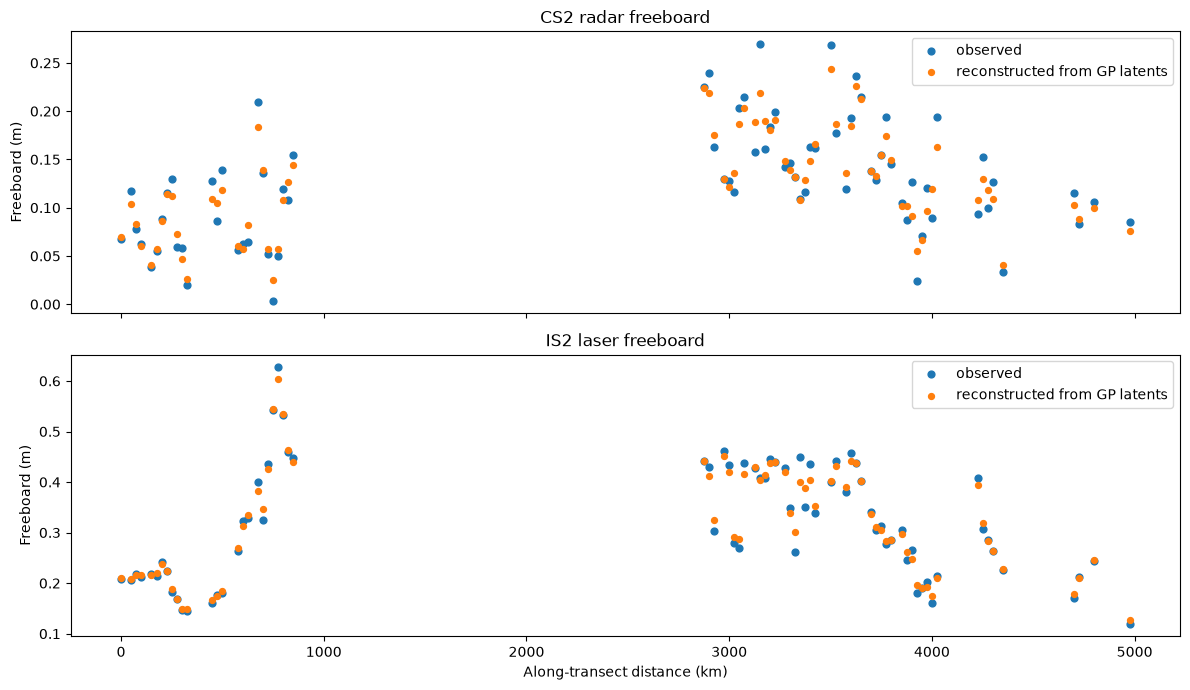

In [10]:
fig, axs = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
labels = ['CS2 radar freeboard', 'IS2 laser freeboard']
for j, ax in enumerate(axs):
    ax.scatter(distance_km, Y[:,j], s=24, label='observed')
    ax.scatter(distance_km, Y_reconstructed[:,j], s=18, label='reconstructed from GP latents')
    ax.set_ylabel('Freeboard (m)')
    ax.set_title(labels[j])
    ax.legend(loc='best')
axs[-1].set_xlabel('Along-transect distance (km)')
plt.tight_layout()


## Interpretation boundaries and next checks

This notebook demonstrates that real CPOM CS2/IS2 observations can be passed
through the same latent multi-output likelihood as the synthetic experiment.
It does **not** establish retrieval accuracy.

Before using these estimates in the dissertation results chapter:

1. verify CS2 and IS2 quality flags and the treatment of negative freeboard;
2. document why this processing uses a 15-day window despite the `7_days` path;
3. replace constant noise with justified sensor and aggregation uncertainty;
4. test densities, $c_s$ and penetration factors;
5. compare fixed-independent, correlated and trainable output priors;
6. use spatially blocked validation rather than training residuals;
7. connect mooring/airborne validation data;
8. compare the same transect with DRF and then scale to 2D using SVGP/DRF.
